<a href="https://colab.research.google.com/github/keirkwame/axionEmu/blob/main/Open_access_of_2e5_emulator_NN_tt.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import tensorflow as tf

# setting the seed for reproducibility
with tf.device('/device:GPU:1'):
    import numpy as np
    import matplotlib.pyplot as plt
    import os
    np.random.seed(2)
    tf.random.set_seed(4)

#from google.colab import drive
#drive.mount('/content/drive')

2025-12-19 08:46:40.883672: E external/local_xla/xla/stream_executor/cuda/cuda_dnn.cc:9261] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
2025-12-19 08:46:40.883711: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:607] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
2025-12-19 08:46:40.884926: E external/local_xla/xla/stream_executor/cuda/cuda_blas.cc:1515] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
2025-12-19 08:46:40.891154: I tensorflow/core/platform/cpu_feature_guard.cc:182] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
2025-12-19 08:46:41.495413: W tensorflow/compiler/tf2

In [2]:
with tf.device('/device:GPU:1'):
    model_parameters = ['h', 
                        'tau_reio', 
                        'omega_b', 
                        'n_s', 
                        'ln10A_s', 
                        'omega_cdm',
                        'log10ma',
                        'omega_ax' 
                        ]

In [3]:
with tf.device('/device:GPU:1'):
    import pickle
    collection_list = []
    num_pkl_files = 60 #Set this number to loop over all the .pkl files that you generated
    c_ell_name = 'sigma8' #C_tt' #Pick which C_ell you would like to emulate

    for i in np.linspace(0, num_pkl_files-1,num_pkl_files):
        f = open('/home/keir/keir/data_derived_params_LH_ACT_DR6_TTTEEEPP_200k_axion_'+str(int(i))+'.pkl', 'rb') #C_ell
        collection = pickle.load(f)
        f.close()
        print(len(collection[c_ell_name]))
        collection_list.append(collection)

    import random
    random.shuffle(collection_list)

3260
3254
3246
3233
3255
3255
3247
3246
3255
3251
3239
3254
3250
3238
3254
3261
3271
3238
3240
3233
3247
3237
3249
3244
3243
3241
3256
3245
3256
3246
3245
3235
3243
3253
3235
3247
3265
3241
3244
3253
3245
3248
3253
3253
3241
3229
3232
3233
3245
3254
3246
3251
3257
3235
3245
3258
3244
3247
3252
3246


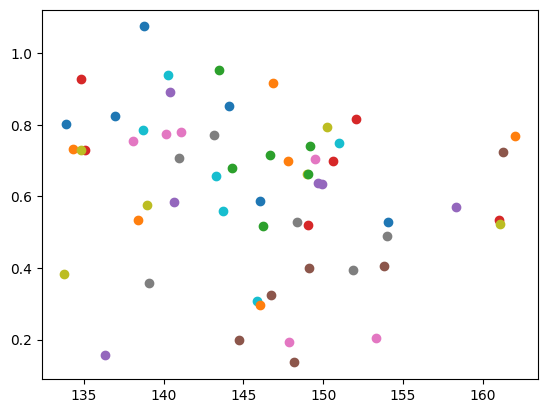

In [4]:
#for i in range(2):
#    print(collection_list[i])
for i in range(60):
    for j in range(1):
        #plt.plot(collection_list[i]['zBAO'][j], collection_list[i]['HBAO'][j]) #* 1.e+7 / (2. * 3.14)
        plt.scatter(collection_list[i]['rs_drag'][j], collection_list[i]['sigma8'][j])
        #plt.plot(collection_list[i]['zBAO'][j], np.log10(collection_list[i]['rsBAO'][j]))
    #print(collection_list[i]) #['HBAO'])
    #print(len(collection_list[i]['HBAO']))
plt.xscale('linear')
#plt.yscale('log')


In [ ]:
#for i in range(2):
#    print(collection_list[i])
for i in [0,1,2,4,5,6,7,8,9]: #range(0, 10):
    for j in range(1):
        plt.plot(collection_list[i]['zBAO'], collection_list[i]['rsBAO']) #* 1.e+7 / (2. * 3.14)
        print(collection_list[i]['100*theta_d'][j])
plt.xscale('log')
plt.yscale('log')


In [ ]:
cut_array = (parameters_list['ma'] < 1.e-25) * (parameters_list['omega_ax'] > 0.1)
print(cut_array.shape)
print(np.sum(cut_array))


In [5]:
with tf.device('/device:GPU:1'):
    parameters_list = {}
    for key in collection['params']:
        parameters_list[key] = np.array([])

    C_list = []
    C_list2 = []
    C_list3 = []

    for i in range(num_pkl_files):
        para = collection_list[i]['params']
        C_list.extend(collection_list[i][c_ell_name])
        C_list2.extend(collection_list[i]['100*theta_s'])
        C_list3.extend(collection_list[i]['rs_drag'])
        for key in para:
          parameters_list[key] = np.concatenate((parameters_list[key], para[key]))

    ell_range = np.array([0, 1, 2]) #Specify here for what ell range you want to emulate
    print(ell_range)
    print(len(C_list), len(C_list2), len(C_list3))
    spectra_= np.concatenate((np.array(C_list)[:, np.newaxis], np.array(C_list2)[:, np.newaxis], np.array(C_list3)[:, np.newaxis]), axis=1)
    print(spectra_.shape)

    #Remove nan spectra
    spectra_bool = np.array(np.sum(~np.isfinite(spectra_), axis=1), dtype=bool)
    print(spectra_bool)
    spectra_ = spectra_[~spectra_bool, :]
    for key in parameters_list.keys():
        parameters_list[key] = parameters_list[key][~spectra_bool]
        print(parameters_list[key].shape)
    print(spectra_.shape)

    #Remove bad spectra
    cut_array = (parameters_list['ma'] < 1.e-25) * (parameters_list['omega_ax'] > 0.1)
    print(np.sum(cut_array))
    spectra_ = spectra_[~cut_array, :]
    for key in parameters_list.keys():
        parameters_list[key] = parameters_list[key][~cut_array]
        print(parameters_list[key].shape)
    print(spectra_.shape)

    #Remove bad spectra #2
    cut_array2 = (parameters_list['ma'] < 5.e-26) * (parameters_list['omega_ax'] > 0.03)
    print(np.sum(cut_array2))
    spectra_ = spectra_[~cut_array2, :]
    for key in parameters_list.keys():
        parameters_list[key] = parameters_list[key][~cut_array2]
        print(parameters_list[key].shape)
    print(spectra_.shape)

    cut_off = 120000 #This splits the dataset into training and test sets at this cut-off number
    import copy
    training_parameters_ = copy.deepcopy(parameters_list)
    h_0 = training_parameters_['H_0'][:cut_off]/100
    ln10_10A_s = np.log(training_parameters_['A_s'][:cut_off]*10**10)
    ma_mass = np.array(training_parameters_['ma'][:cut_off]*10**32,dtype='float64')
    ma_mass = np.log10(ma_mass) #We define axion mass as the logarithmic difference to -32, e.g., 10^-27 eV is 5
    training_parameters = dict()
    training_parameters['omega_b'] = training_parameters_['omega_b'][:cut_off]
    training_parameters['omega_cdm'] = training_parameters_['omega_cdm'][:cut_off]
    training_parameters['h'] = h_0
    training_parameters['tau_reio'] = training_parameters_['tau_reio'][:cut_off]
    training_parameters['n_s'] = training_parameters_['n_s'][:cut_off]
    training_parameters['ln10A_s'] = ln10_10A_s
    training_parameters['log10ma'] = ma_mass
    training_parameters['omega_ax'] = training_parameters_['omega_ax'][:cut_off]

    test_parameters_ = copy.deepcopy(parameters_list)
    h_0 = test_parameters_['H_0'][cut_off:]/100
    ln10_10A_s = np.log(test_parameters_['A_s'][cut_off:]*10**10)
    ma_mass = np.array(test_parameters_['ma'][cut_off:]*10**32, dtype = 'float64')
    ma_mass = np.log10(ma_mass)
    test_parameters = dict()
    test_parameters['omega_b'] = test_parameters_['omega_b'][cut_off:]
    test_parameters['omega_cdm'] = test_parameters_['omega_cdm'][cut_off:]
    test_parameters['h'] = h_0
    test_parameters['tau_reio'] = test_parameters_['tau_reio'][cut_off:]
    test_parameters['n_s'] = test_parameters_['n_s'][cut_off:]
    test_parameters['ln10A_s'] = ln10_10A_s
    test_parameters['omega_ax'] = test_parameters_['omega_ax'][cut_off:]
    test_parameters['log10ma'] = ma_mass

    training_spectra = spectra_[:cut_off,:]
    testing_spectra = spectra_[cut_off:,:]
    print('number of training spectra: ', training_spectra.shape)
    print('number of testing spectra: ', testing_spectra.shape)


[0 1 2]
194819 194819 194819
(194819, 3)
[False False False ... False False False]
(194819,)
(194819,)
(194819,)
(194819,)
(194819,)
(194819,)
(194819,)
(194819,)
(194819,)
(194819,)
(194819,)
(194819, 3)
13095
(181724,)
(181724,)
(181724,)
(181724,)
(181724,)
(181724,)
(181724,)
(181724,)
(181724,)
(181724,)
(181724,)
(181724, 3)
48601
(133123,)
(133123,)
(133123,)
(133123,)
(133123,)
(133123,)
(133123,)
(133123,)
(133123,)
(133123,)
(133123,)
(133123, 3)
number of training spectra:  (120000, 3)
number of testing spectra:  (13123, 3)


In [ ]:
%matplotlib inline
plt.plot(ell_range, (10. ** training_log_spectra[0]) * ell_range * (ell_range + 1) / 2. / np.pi)
plt.plot(ell_range, (10. ** training_log_spectra[-1]) * ell_range * (ell_range + 1) / 2. / np.pi)


In [6]:
with tf.device('/device:GPU:1'):
    test_collection = {}
    test_collection['training_parameters'] = training_parameters
    test_collection['test_parameters'] = test_parameters
    test_collection['training_spectra'] = training_spectra
    test_collection['testing_spectra'] = testing_spectra
    import pickle
    f = open('data_training_test_ACT_DR6_derived3_200k_axion_cut2.pkl', 'wb')
    pickle.dump(test_collection, f)
    f.close()


In [ ]:
##Only for Google Colab
!git clone https://github.com/keirkwame/axionEmu.git

In [7]:
# instantiate NN class
with tf.device('/device:GPU:1'): # ensures we are running on a GPU
    from axionEmu.cosmopower import cosmopower_NN
    cp_nn = cosmopower_NN(parameters=model_parameters, 
                      modes=ell_range, 
                      n_hidden = [512, 512, 512,512], # 4 hidden layers, each with 512 nodes
                      verbose=True, # useful to understand the different steps in initialisation and training
                      )



Initialized cosmopower_NN model, 
mapping 8 input parameters to 3 output modes, 
using 4 hidden layers, 
with [512, 512, 512, 512] nodes, respectively. 



In [8]:
with tf.device('/device:GPU:1'): # ensures we are running on a GPU
    # train
    cp_nn.train(training_parameters=training_parameters,
                training_features=training_spectra,
                filename_saved_model='derived3_NN_axion_emulator_ACT_DR6_200k_cut2', #Give a name to the emulator file
                # cooling schedule
                validation_split=0.1,
                learning_rates=[1e-2, 1e-3, 1e-4, 1e-5, 1e-6, 1e-7],
                batch_sizes=[1024,1024,1024,1024,1024,1024],
                gradient_accumulation_steps = [1, 1, 1, 1, 1, 1],
                # early stopping set up
                patience_values = [100,100,100,100,100,100],
                max_epochs = [1000,1000,1000,1000,1000,1000],
                )


Starting cosmopower_NN training, 
using 10 per cent of training samples for validation. 
Performing 6 learning steps, with 
[0.01, 0.001, 0.0001, 1e-05, 1e-06, 1e-07] learning rates 
[1024, 1024, 1024, 1024, 1024, 1024] batch sizes 
[1, 1, 1, 1, 1, 1] gradient accumulation steps 
[100, 100, 100, 100, 100, 100] patience values 
[1000, 1000, 1000, 1000, 1000, 1000] max epochs 

learning rate = 0.01, batch size = 1024


2025-12-19 08:50:13.394514: W external/local_xla/xla/service/gpu/llvm_gpu_backend/gpu_backend_lib.cc:504] Can't find libdevice directory ${CUDA_DIR}/nvvm/libdevice. This may result in compilation or runtime failures, if the program we try to run uses routines from libdevice.
Searched for CUDA in the following directories:
  ./cuda_sdk_lib
  /usr/local/cuda-12.2
  /usr/local/cuda
  /home/keir/miniconda3/envs/axionemu/lib/python3.11/site-packages/tensorflow/python/platform/../../../nvidia/cuda_nvcc
  /home/keir/miniconda3/envs/axionemu/lib/python3.11/site-packages/tensorflow/python/platform/../../../../nvidia/cuda_nvcc
  .
You can choose the search directory by setting xla_gpu_cuda_data_dir in HloModule's DebugOptions.  For most apps, setting the environment variable XLA_FLAGS=--xla_gpu_cuda_data_dir=/path/to/cuda will work.
  0%|                                                                                                                                                                

 14%|████████████████████▋                                                                                                                                   | 136/1000 [03:36<22:56,  1.59s/it, loss=0.132]


Validation loss = 0.043197926
Model saved.
Reached max number of epochs. Validation loss = 0.043197926
Model saved.
learning rate = 0.001, batch size = 1024


 30%|█████████████████████████████████████████████▍                                                                                                         | 301/1000 [07:43<17:55,  1.54s/it, loss=0.0124]


...

Validation loss = 0.0019446148
Model saved.
Reached max number of epochs. Validation loss = 0.0019446148
Model saved.
learning rate = 1e-06, batch size = 1024


 11%|█████████████████                                                                                                                                      | 113/1000 [03:19<26:09,  1.77s/it, loss=0.0102]


Validation loss = 0.010194549
Model saved.
Reached max number of epochs. Validation loss = 0.010194549
Model saved.
learning rate = 1e-07, batch size = 1024


 10%|███████████████                                                                                                                                       | 100/1000 [02:53<25:57,  1.73s/it, loss=0.00731]

Validation loss = 0.0072712046
Model saved.
Reached max number of epochs. Validation loss = 0.0072712046
Model saved.


In [9]:
with tf.device('/device:GPU:1'): # ensures we are running on a GPU
    cp_nn = cosmopower_NN(restore=True, 
                          restore_filename='derived3_NN_axion_emulator_ACT_DR6_200k_cut2',
                          )


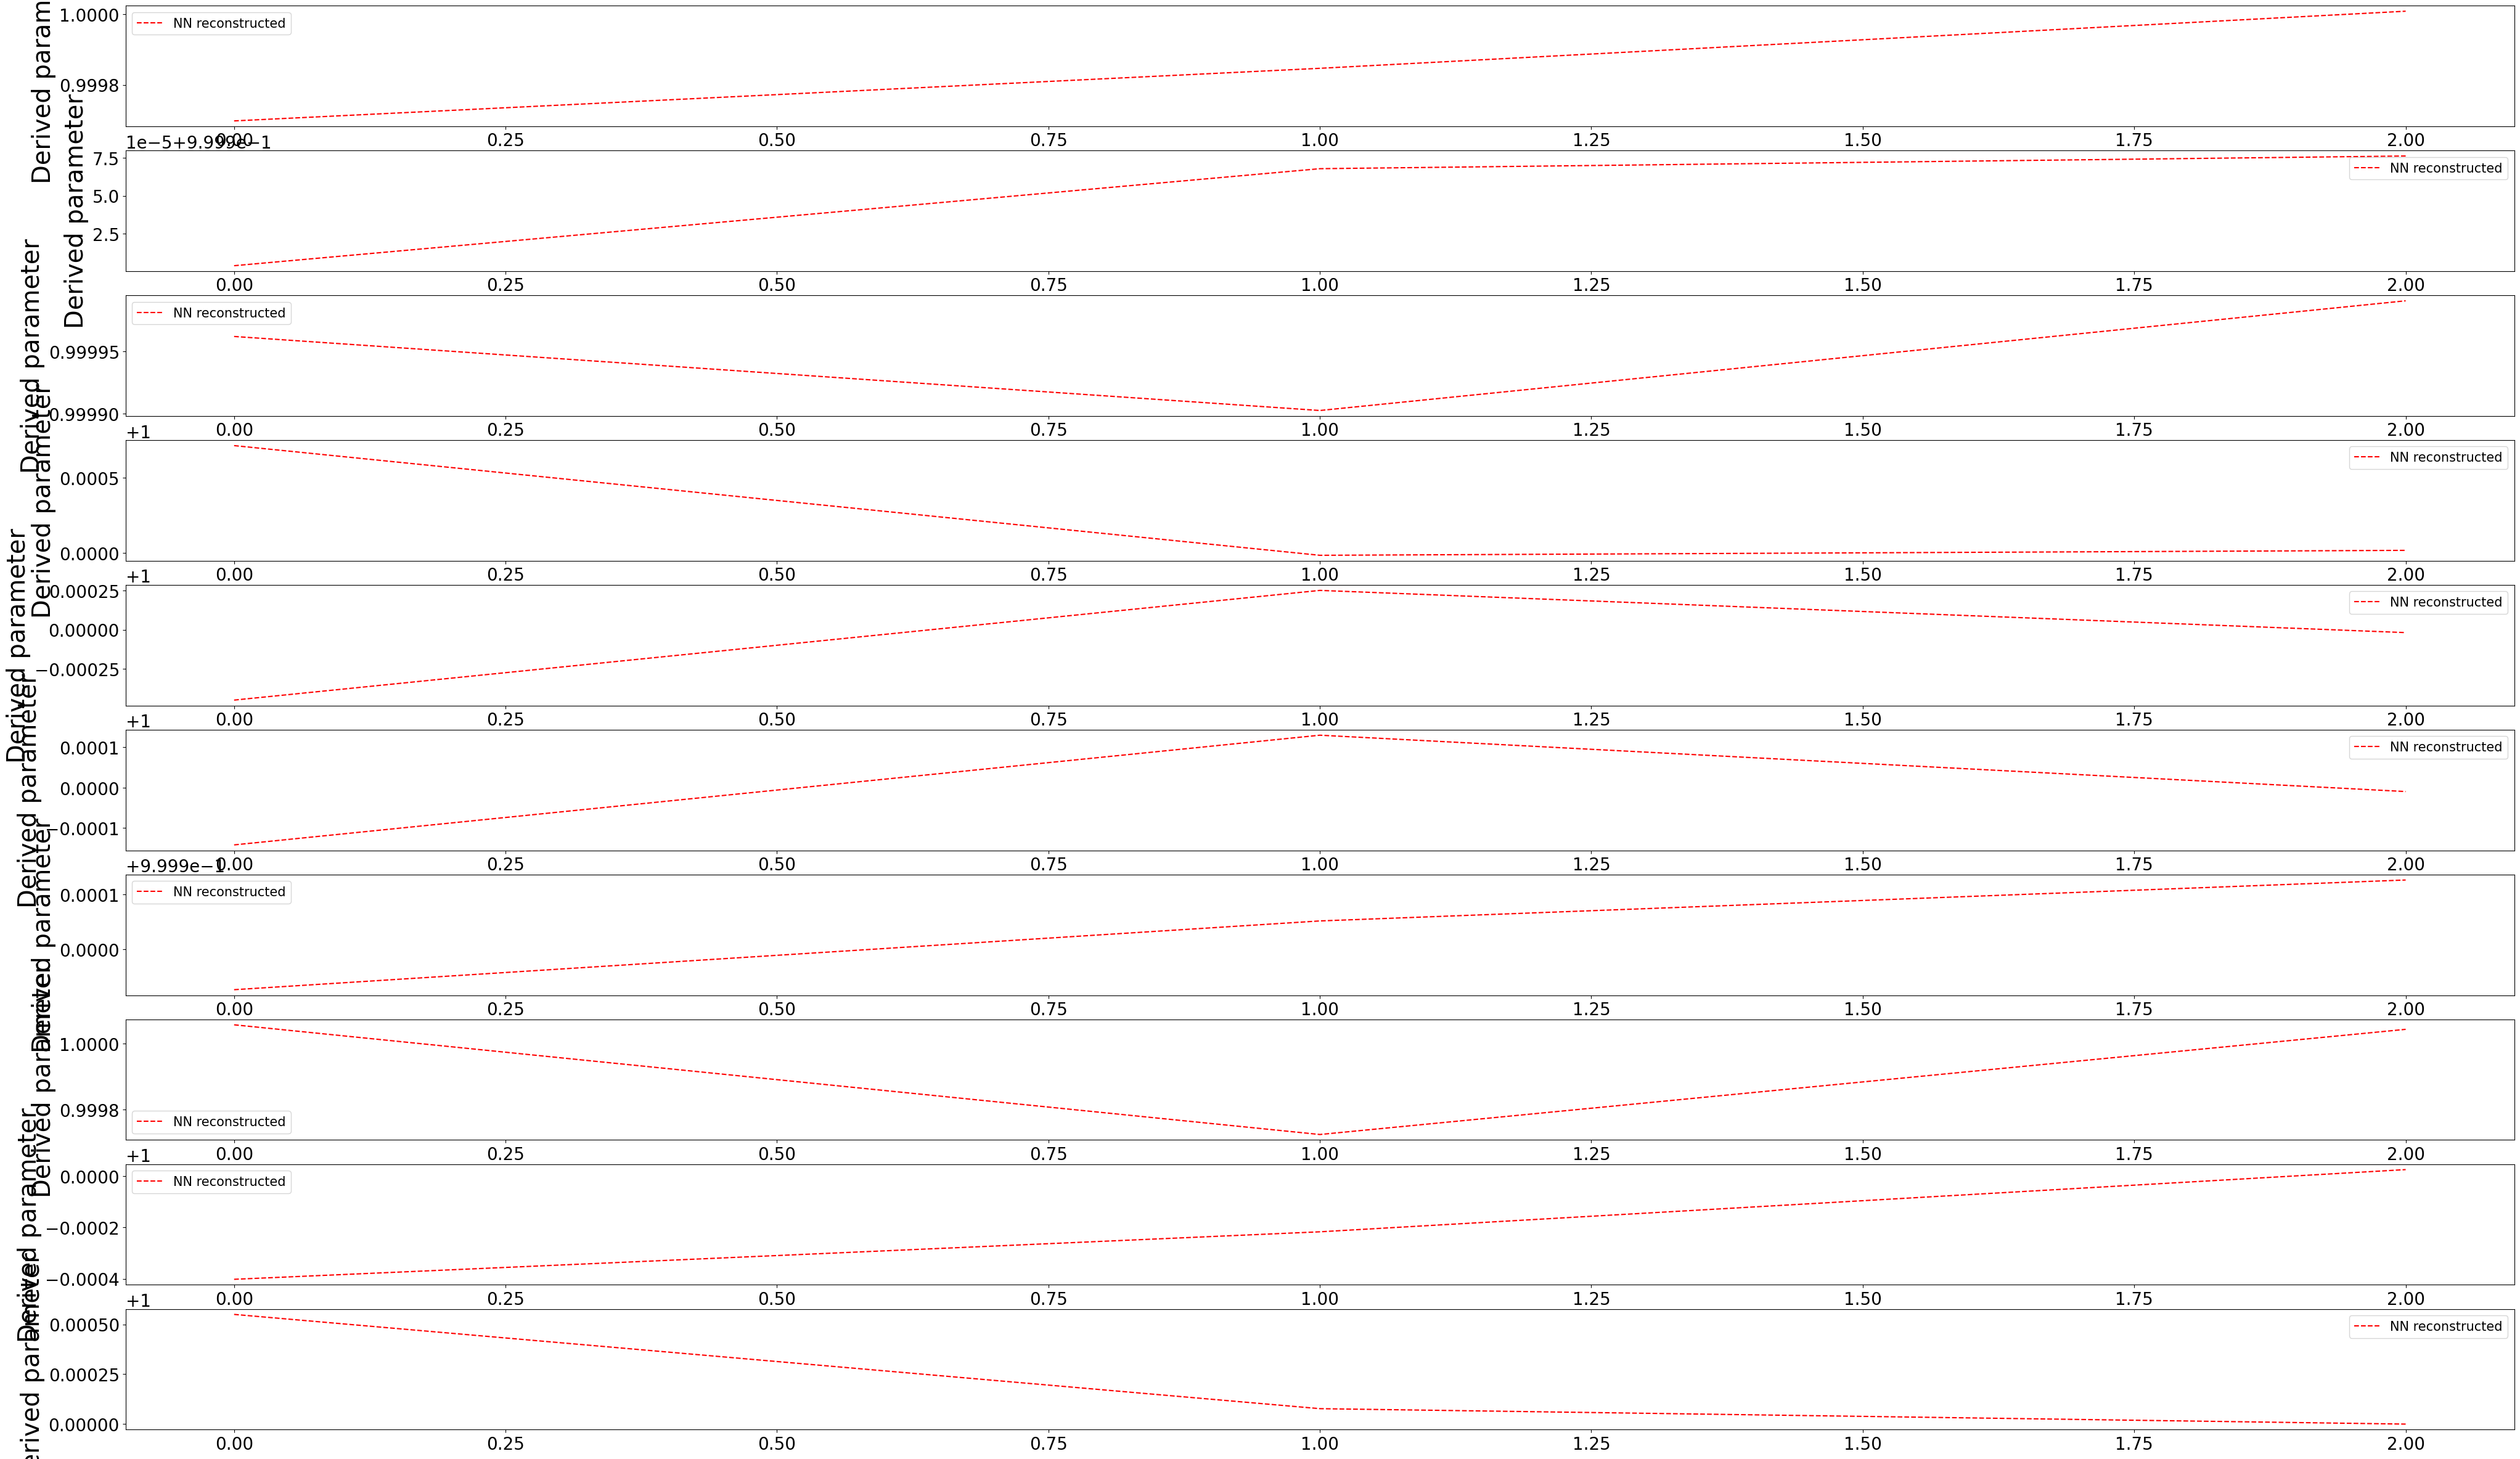

In [10]:
with tf.device('/device:GPU:1'): # ensures we are running on a GPU
    predicted_testing_spectra = cp_nn.predictions_np(test_parameters)
    import matplotlib.pyplot as plt
    from matplotlib import gridspec
    plt.rcParams['font.size'] = '20'
    fig, ax = plt.subplots(nrows=10, ncols=1, figsize=(50,30))
    for i in range(10):
        pred = predicted_testing_spectra[i]#*ell_range*(ell_range+1)/(2.*np.pi)
        true = testing_spectra[i]#*ell_range*(ell_range+1)/(2.*np.pi)
        #ax[i].plot(ell_range, true, 'blue', label = 'Original')
        ax[i].plot(ell_range, pred / true, 'red', label = 'NN reconstructed', linestyle='--')
        #ax[i].set_xlabel('$\ell$', fontsize='x-large')
        ax[i].set_ylabel('Derived parameter', fontsize='x-large')
        ax[i].legend(fontsize=15)
    plt.savefig('examples_reconstruction_derived3_axion_ACT_DR6_200k_cut2.pdf')


In [ ]:
#Make a plot of the axion mass -- omega_axion training/test samples

print(np.sum(np.isnan(spectra_)) / np.size(spectra_))
print(parameters_list.keys())
for i in range(spectra_.shape[0]):
    if np.sum(~np.isnan(spectra_[i])):
        plt.scatter(np.log10(parameters_list['ma'][i]), parameters_list['omega_ax'][i])


In [ ]:
##Only for Google Colab
!git clone https://github.com/simonsobs/so_noise_models

diff_.shape is  (13123,)


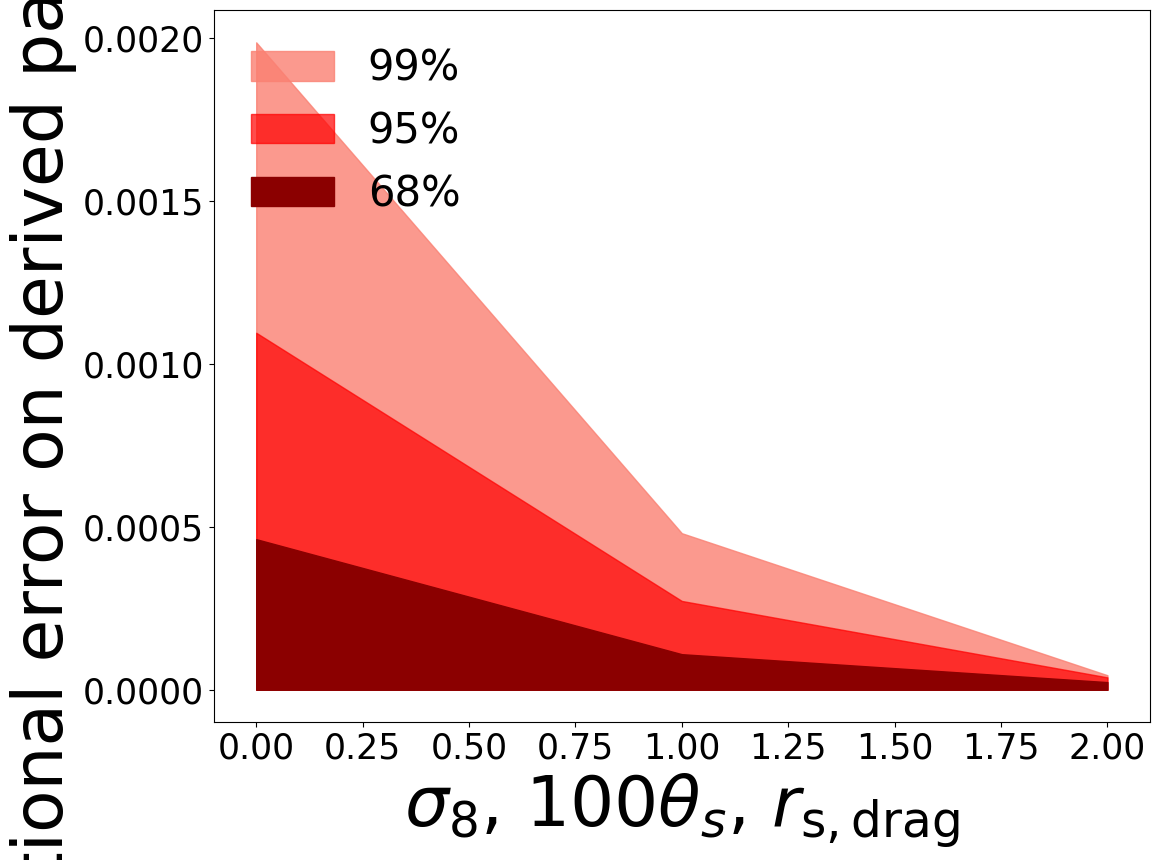

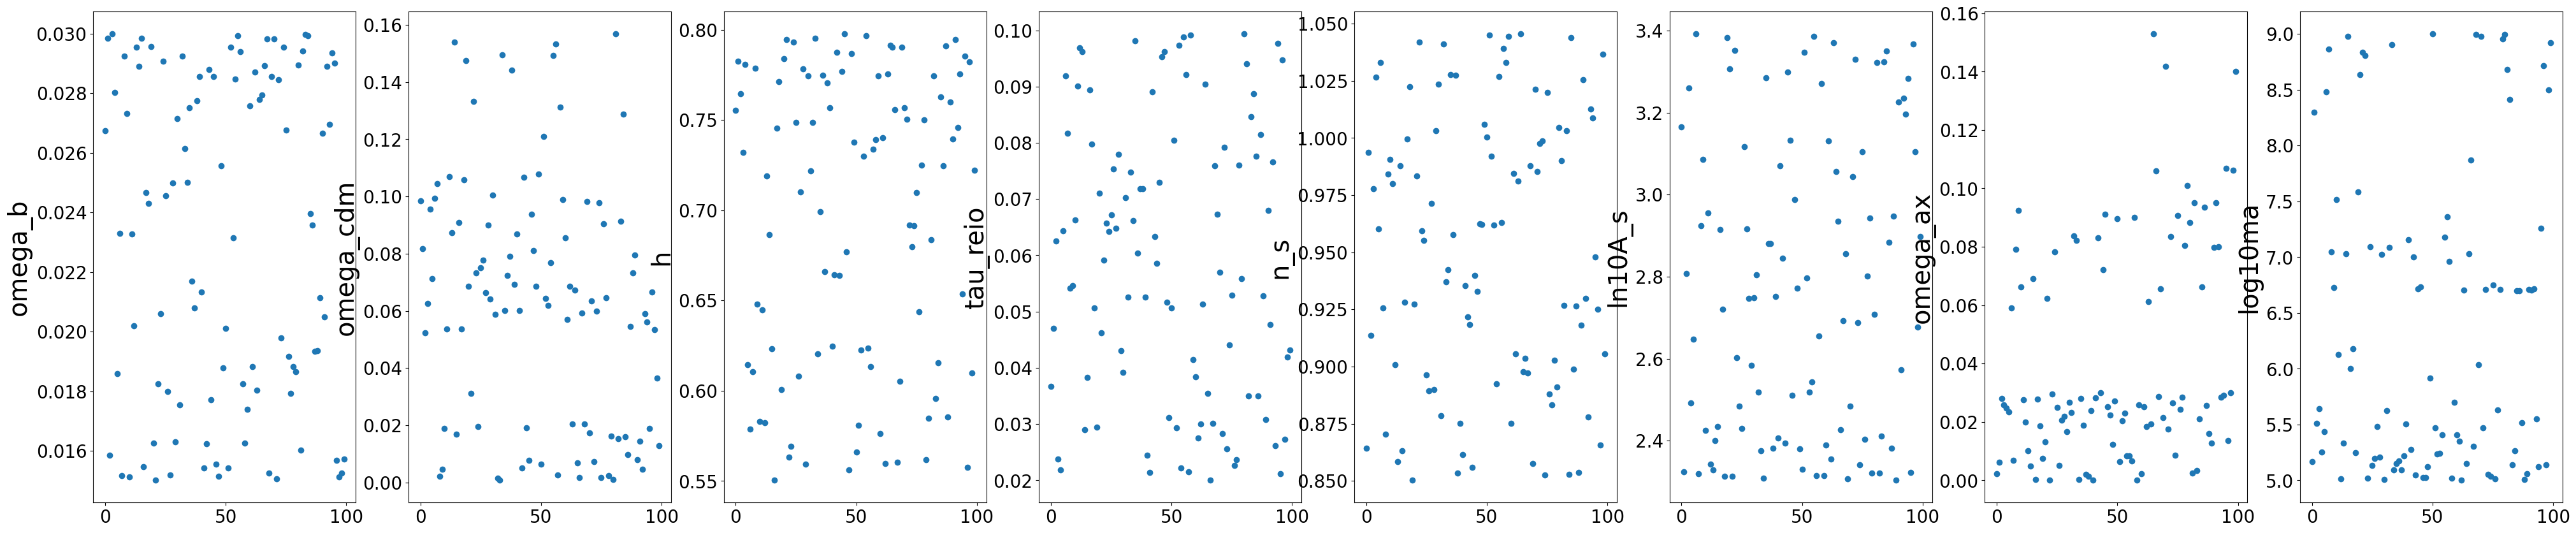

In [11]:
with tf.device('/device:GPU:1'): # ensures we are running on a GPU
    # load noise models from the SO noise repo
    '''noise_levels_load = np.loadtxt('./so_noise_models/LAT_comp_sep_noise/v3.1.0/SO_LAT_Nell_T_atmv1_goal_fsky0p4_ILC_CMB.txt')
    conv_factor = (2.7255e6)**2

    ells = noise_levels_load[:, 0]
    SO_TT_noise = noise_levels_load[:, 1][:np.max(ell_range)+1-40] / conv_factor ##6001-40
    new_ells = ells[:np.max(ell_range)+1-40] ##6001-40

    f_sky = 0.4'''
    prefac = 1. #np.sqrt(2/(f_sky*(2*new_ells+1)))

    ##Cut off some spectra
    #print(new_ells)
    #print(prefac.shape, testing_spectra.shape, SO_TT_noise.shape)
    #testing_spectra = testing_spectra[:6001-40]

    denominator = prefac*testing_spectra[:, :]  # use all of them #+SO_TT_noise #38:
    diff = np.abs((predicted_testing_spectra[:, :] - testing_spectra[:, :])/(denominator))

    # Compute percentiles
    percentiles = np.zeros((4, diff.shape[1]))

    percentiles[0] = np.percentile(diff, 68, axis = 0)
    percentiles[1] = np.percentile(diff, 95, axis = 0)
    percentiles[2] = np.percentile(diff, 99, axis = 0)
    percentiles[3] = np.percentile(diff, 99.9, axis = 0)

    plt.figure(figsize=(12, 9))
    plt.fill_between(ell_range, 0, percentiles[2,:], color = 'salmon', label = '99%', alpha=0.8)
    plt.fill_between(ell_range, 0, percentiles[1,:], color = 'red', label = '95%', alpha = 0.7)
    plt.fill_between(ell_range, 0, percentiles[0,:], color = 'darkred', label = '68%', alpha = 1)

    # plt.ylim(0, 0.2)

    plt.legend(frameon=False, fontsize=30, loc='upper left')
    plt.ylabel(r'Fractional error on derived parameter', fontsize=50)
    plt.xlabel(r'$\sigma_8$, $100 \theta_s$, $r_{\rm{s, drag}}$',  fontsize=50)
    plt.xscale('linear')

    #plt.axhline(y=0.01)
    #plt.axvline(x=np.log10(40))
    #plt.xscale('log')

    ax = plt.gca()
    ax.xaxis.set_major_locator(plt.MaxNLocator(10))
    ax.yaxis.set_major_locator(plt.MaxNLocator(5))

    plt.setp(ax.get_xticklabels(), fontsize=25)
    plt.setp(ax.get_yticklabels(), fontsize=25)
    plt.tight_layout()
    plt.savefig('./accuracy_emu_derived3_ACT_DR6_axion_200k_cut2.pdf')

    diff_=np.sum(diff,axis = 1)
    print('diff_.shape is ', diff_.shape)
    sort_index = np.argsort(diff_)
    bad_params = dict()
    for key in test_parameters:
        bad_params[key] = []
    for i in sort_index[len(sort_index)-100:]:
        for key in test_parameters:
            bad_params[key].append(test_parameters[key][i])
    fig, ax = plt.subplots(nrows=1, ncols=8, figsize=(50,10))
    for i in range(8):
        pa =list(test_parameters.keys())[i]
        h = bad_params[pa]
        ax[i].plot(h, 'o')
        ax[i].set_ylabel(pa, fontsize='x-large')
    plt.savefig('worst_params_derived_3ACT_DR6_axion_200k_cut2.pdf')
